<a href="https://colab.research.google.com/github/IKM-Products/Concrete-Strength-Prediction-Using-XGBoost-and-RandomForest/blob/main/Concrete_Strength_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
!pip install xgboost

In [51]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Concrete Compressive Strength.csv")

In [52]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [53]:
df.shape

(1030, 9)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Cement                          1030 non-null   float64
 1   Blast Furnace Slag              1030 non-null   float64
 2   Fly Ash                         1030 non-null   float64
 3   Water                           1030 non-null   float64
 4   Superplasticizer                1030 non-null   float64
 5   Coarse Aggregate                1030 non-null   float64
 6   Fine Aggregate                  1030 non-null   float64
 7   Age (day)                       1030 non-null   int64  
 8   Concrete compressive strength   1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [55]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [56]:
(df == 0).sum()

,0
Cement,0
Blast Furnace Slag,466
Fly Ash,566
Water,0
Superplasticizer,379
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [57]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age (day),0
Concrete compressive strength,0


In [58]:
df.duplicated().sum()

np.int64(25)

In [59]:
df = df.drop_duplicates()

print(df.duplicated().sum())
print(df.shape)

0
(1005, 9)


In [60]:
X = df.drop("Concrete compressive strength ", axis=1)
y = df["Concrete compressive strength "]

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [63]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [64]:
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("----------------------")

In [65]:
evaluate_model("Random Forest Regressor", y_test, rf_pred)
evaluate_model("XGBoost Regressor", y_test, xgb_pred)

Random Forest Regressor
MAE: 3.4885639853826964
RMSE: 5.152688066104909
R2 Score: 0.9110033917355721
----------------------
XGBoost Regressor
MAE: 3.2538510798051
RMSE: 4.732473671727244
R2 Score: 0.9249272776536948
----------------------


In [66]:
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring="r2")

print("Random Forest CV Mean:", rf_cv.mean())
print("Random Forest CV Std:", rf_cv.std())

print("XGBoost CV Mean:", xgb_cv.mean())
print("XGBoost CV Std:", xgb_cv.std())

Random Forest CV Mean: 0.3158796206955863
Random Forest CV Std: 0.8535185983092128
XGBoost CV Mean: 0.4764108662415163
XGBoost CV Std: 0.6352036531057003


In [67]:
joblib.dump(xgb_model, "concrete_strength_xgboost_model.pkl")
joblib.dump(rf_model, "concrete_strength_random_forest_model.pkl")

['concrete_strength_random_forest_model.pkl']

In [68]:
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("RF Train R2:", rf_train_r2)
print("RF Test R2:", rf_test_r2)

RF Train R2: 0.9846773892320125
RF Test R2: 0.9110033917355721


In [69]:
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("XGB Train R2:", xgb_train_r2)
print("XGB Test R2:", xgb_test_r2)

XGB Train R2: 0.9739359332582828
XGB Test R2: 0.9249272776536948


In [70]:
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

[ 0.77192984  0.74328677  0.7819271   0.87578872 -0.79087811]
Mean: 0.4764108662415163
Std: 0.6352036531057003


In [71]:
train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

print(train_rmse)
print(test_rmse)

1.9821515040296371
5.152688066104909


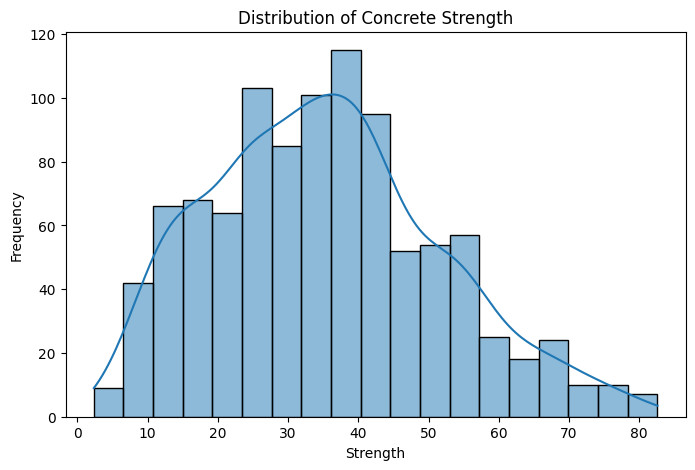

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df["Concrete compressive strength "],
    kde=True
)

plt.title("Distribution of Concrete Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")

plt.show()

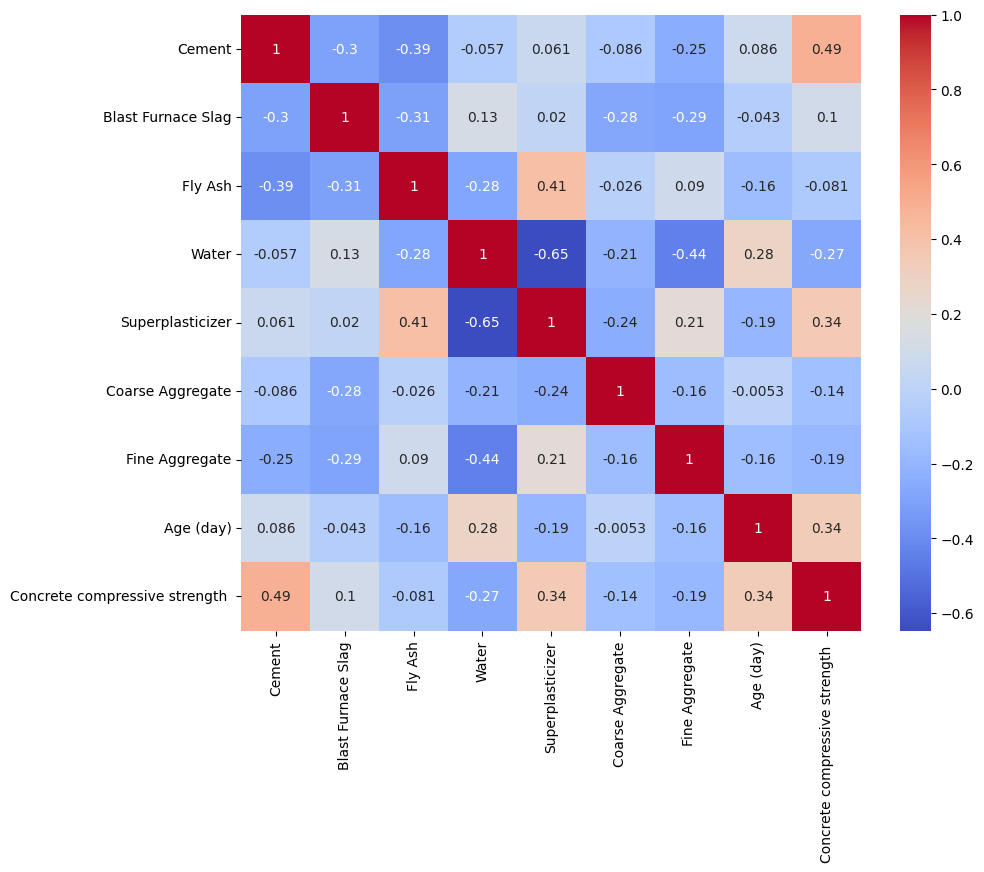

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

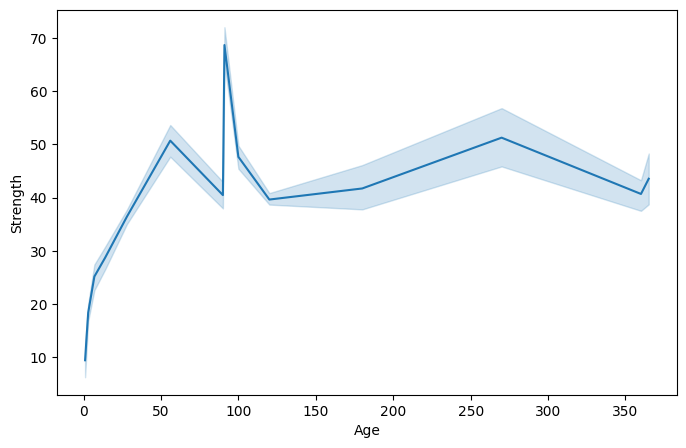

In [74]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=df["Age (day)"],
    y=df["Concrete compressive strength "]
)

plt.xlabel("Age")
plt.ylabel("Strength")

plt.show()

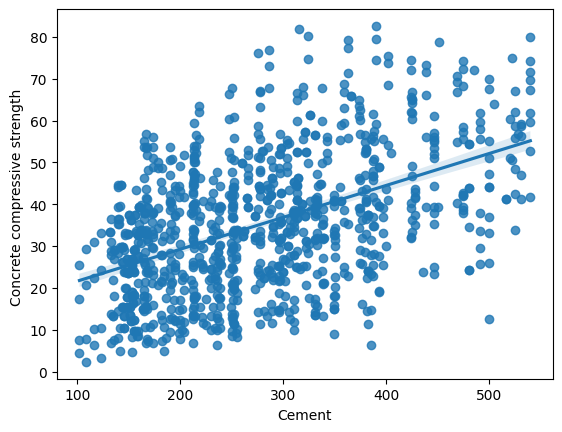

In [75]:
sns.regplot(
    x=df["Cement"],
    y=df["Concrete compressive strength "]
)

plt.show()

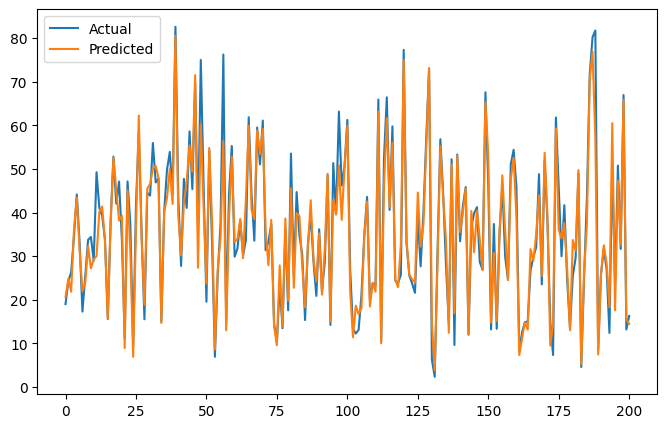

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    xgb_pred,
    label="Predicted"
)

plt.legend()

plt.show()

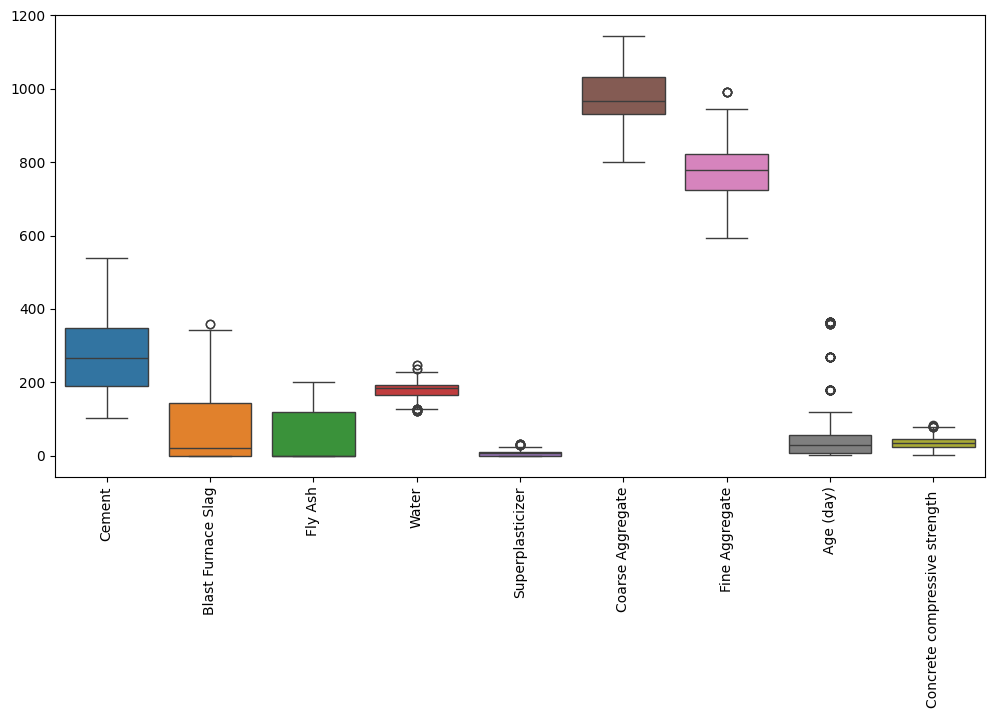

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

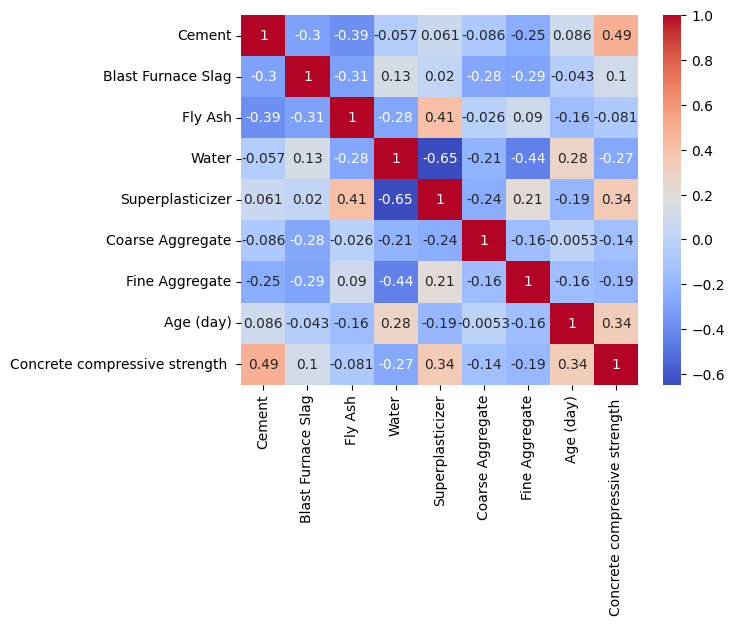

In [78]:
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

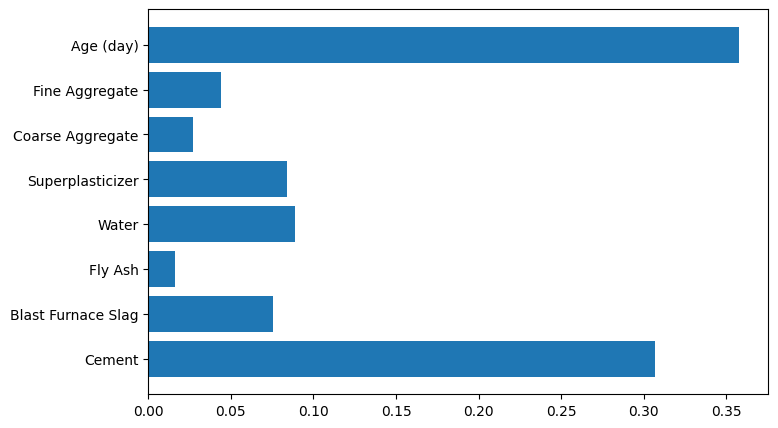

In [79]:
importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.show()

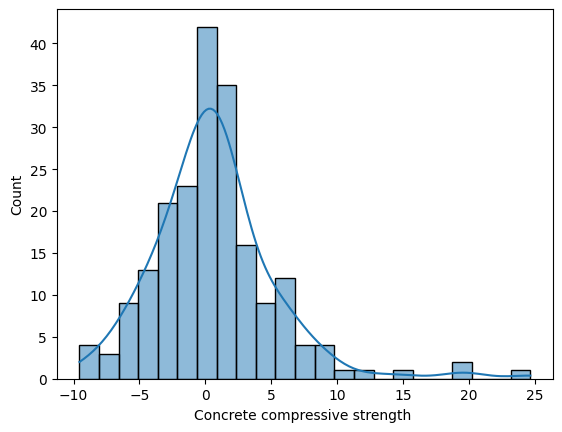

In [80]:
residuals = y_test - xgb_pred

sns.histplot(
    residuals,
    kde=True
)

plt.show()

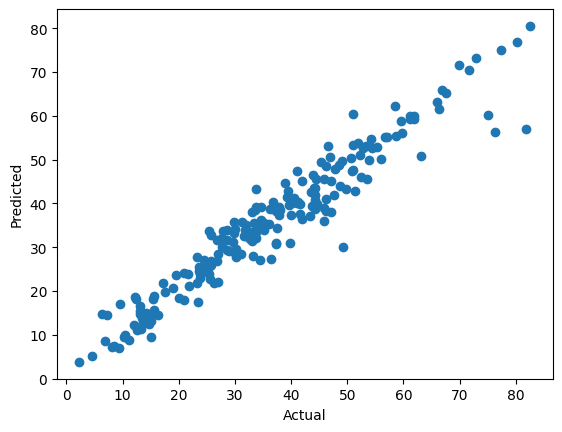

In [81]:
plt.scatter(
    y_test,
    xgb_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

In [82]:
import joblib

joblib.dump(
    xgb_model,
    "concrete_model.pkl"
)

['concrete_model.pkl']

In [83]:
import pandas as pd

sample = pd.DataFrame({
    "Cement": [540],
    "Blast Furnace Slag": [0],
    "Fly Ash": [0],
    "Water": [162],
    "Superplasticizer": [2.5],
    "Coarse Aggregate": [1040],
    "Fine Aggregate": [676],
    "Age (day)": [28]
})

prediction = xgb_model.predict(sample)

print("Predicted Concrete Strength:", prediction[0], "MPa")

Predicted Concrete Strength: 74.992836 MPa


In [84]:
prediction = rf_model.predict(sample)

print(
    "Predicted Concrete Strength:",
    prediction[0],
    "MPa"
)

Predicted Concrete Strength: 73.59225507400022 MPa


In [85]:
new_samples = pd.DataFrame({

"Cement":[540,332],
"Blast Furnace Slag":[0,142],
"Fly Ash":[0,50],
"Water":[162,228],
"Superplasticizer":[2.5,0],
"Coarse Aggregate":[1040,932],
"Fine Aggregate":[676,594],
"Age (day)":[28,90]

})

predictions = xgb_model.predict(new_samples)

print(predictions)

[74.992836 39.286655]
